<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Colors_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Colors in ggplot2: From Palettes to Custom Hex Codes**

### নোটবুক পরিচিতি (Metadata)
- Aim: আর (R) এবং ggplot2 ব্যবহার করে গ্রাফের রঙ নিয়ন্ত্রণ করা শেখা। এখানে আমরা প্রি-বিল্ট প্যালেট থেকে শুরু করে নিজের পছন্দমতো হেক্স কোড ব্যবহারের কৌশল দেখব।
- Dataset: mpg (গাড়ির জ্বালানি সাশ্রয় সংক্রান্ত ডেটা)।
- Key Learnings: RColorBrewer ব্যবহার, ম্যানুয়াল কালার ম্যাপিং, এবং কালারব্লাইন্ডদের জন্য উপযোগী গ্রাফ তৈরি।
- Technique: এখানে geom_jitter() ব্যবহার করা হয়েছে যেন ওভারল্যাপিং পয়েন্টগুলো আলাদাভাবে বোঝা যায়।

### কেন সঠিক রঙ নির্বাচন গুরুত্বপূর্ণ?
- ১. Accessibility: কালারব্লাইন্ড পাঠকদের জন্য গ্রাফটি সহজে বোঝার উপযোগী করা।
- ২. Aesthetics: গ্রাফকে প্রফেশনাল এবং চোখের জন্য আরামদায়ক করা।
- ৩. Context: সঠিক ক্যাটাগরিতে সঠিক রঙ ব্যবহার করে ডেটা স্টোরিটেলিং সহজ করা।

### ১. আরকালার ব্রুওয়ার (RColorBrewer) ও এক্সেসিবিলিটি
পেশাদার গ্রাফ তৈরির জন্য RColorBrewer অত্যন্ত জনপ্রিয়। শুরুতে আমরা দেখে নেব কোন কোন প্যালেটগুলো কালারব্লাইন্ড ফ্রেন্ডলি।

In [1]:
install.packages('RColorBrewer')
library(RColorBrewer)
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


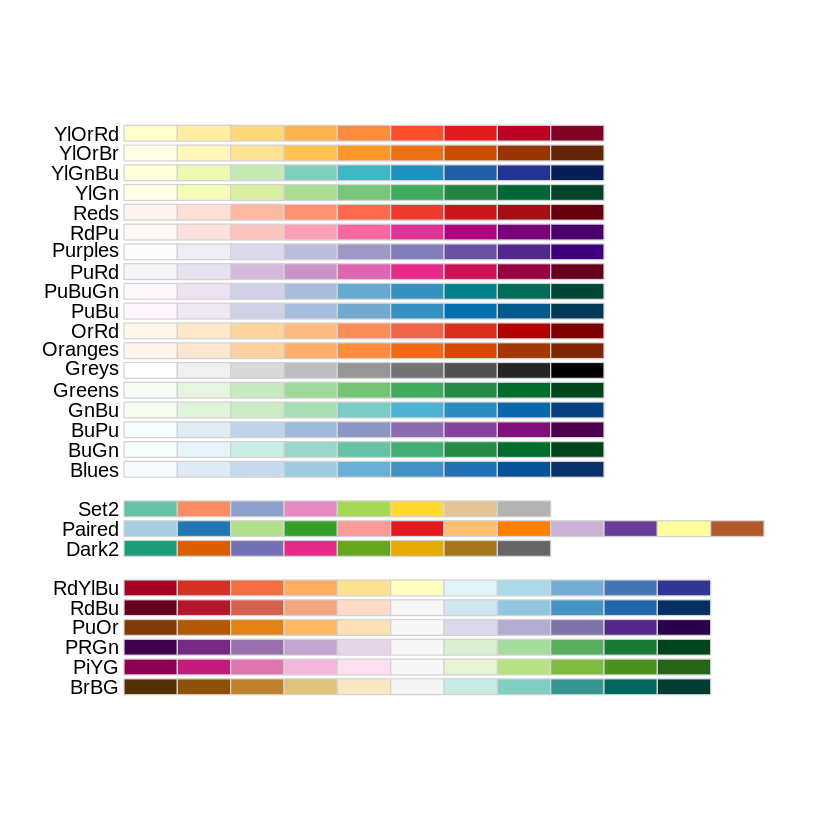

In [2]:
# কালারব্লাইন্ড ফ্রেন্ডলি প্যালেটগুলো দেখা
display.brewer.all(colorblindFriendly = TRUE)

#### টাইপ ১: প্রি-বিল্ট প্যালেট ব্যবহার (Dark2)

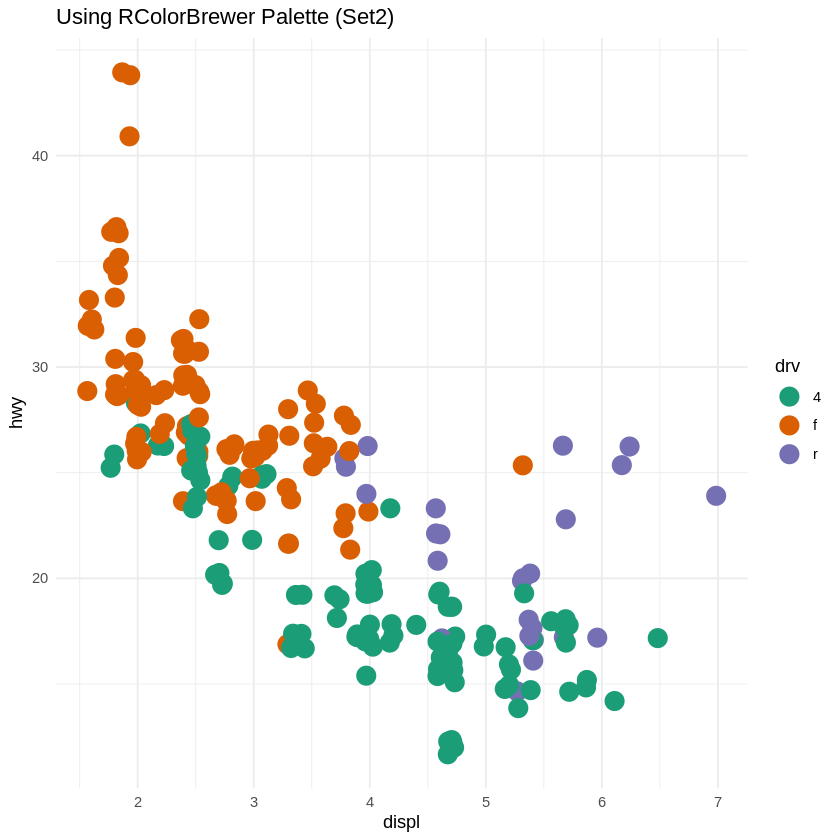

In [3]:
mpg %>%
  ggplot(aes(displ, hwy, color = drv)) +
  geom_jitter(size = 5) +
  scale_color_brewer(palette = "Dark2") + # RColorBrewer প্যালেট
  theme_minimal() +
  labs(title = "Using RColorBrewer Palette (Set2)")

### ২. গ্লোবাল কালার কন্ট্রোল (Global Control)
যদি আপনি গ্রাফের সব বিন্দুকে একটি নির্দিষ্ট রঙ দিতে চান (গ্রুপ না করে), তবে হেক্স কোড ব্যবহার করা সবচেয়ে ভালো উপায়।

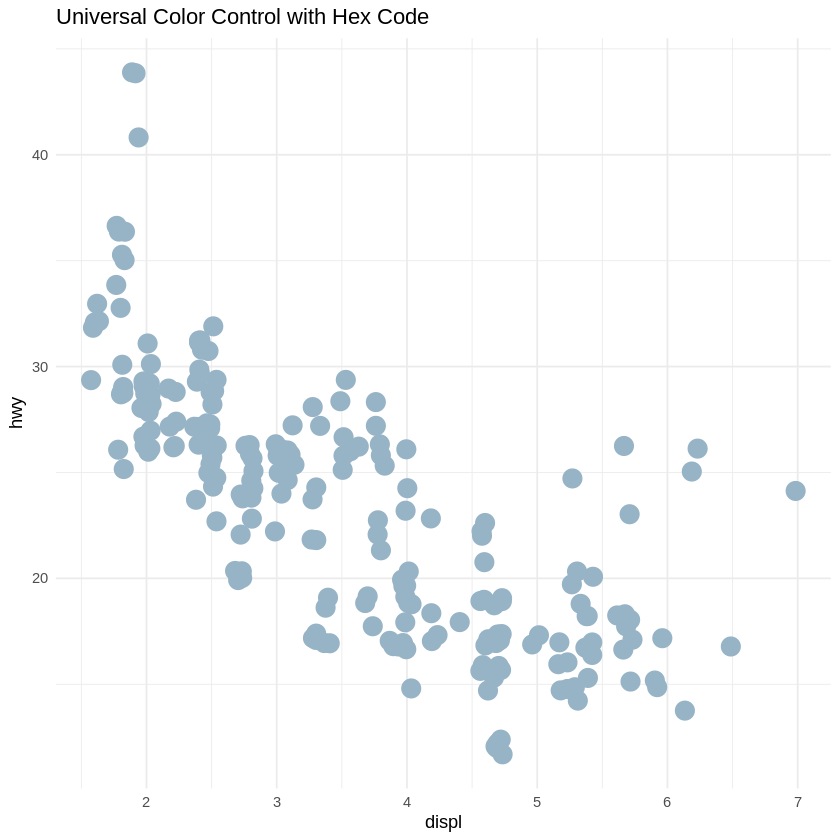

In [4]:
# টাইপ ২: নির্দিষ্ট একটি হেক্স কোড ব্যবহার
mpg %>%
  ggplot(aes(displ, hwy)) +
  geom_jitter(color = "#97B3C6", size = 5) + # সফট ব্লু হেক্স কোড
  theme_minimal() +
  labs(title = "Universal Color Control with Hex Code")

**ব্যাখ্যা:** এখানে রঙের নাম (যেমন: "blue") এর বদলে হেক্স কোড (#97B3C6) ব্যবহার করা হয়েছে যা আপনাকে রঙের সূক্ষ্ম শেড নির্বাচনের স্বাধীনতা দেয়।

### ৩. ম্যানুয়াল কালার ম্যাপিং (Scale Color Manual)
কখনও কখনও আমাদের নির্দিষ্ট ক্যাটাগরির জন্য নির্দিষ্ট রঙ প্রয়োজন হয়। এর জন্য scale_color_manual সেরা সমাধান।

#### টাইপ ৩: রঙের নাম দিয়ে স্পেসিফিক হওয়া

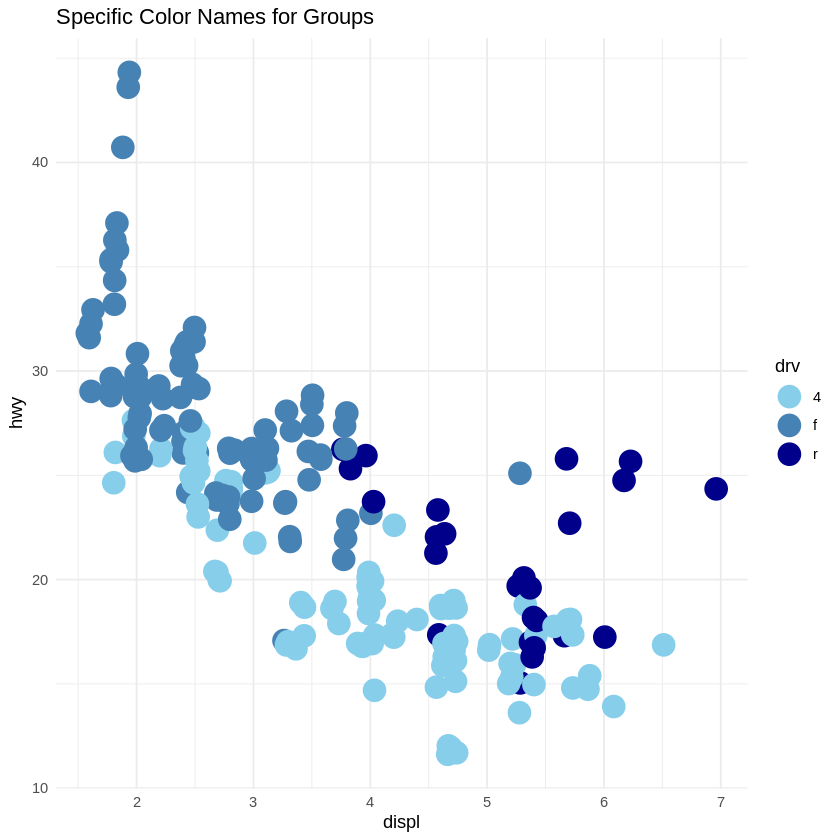

In [5]:
mpg %>%
  ggplot(aes(displ, hwy, color = drv)) +
  geom_jitter(size = 6) +
  scale_color_manual(values = c("4" = "skyblue",
                                "f" = "steelblue",
                                "r" = "darkblue")) +
  theme_minimal() +
  labs(title = "Specific Color Names for Groups")

#### টাইপ ৪: প্রফেশনাল হেক্স কোড ও ট্রান্সপারেন্সি (Alpha)
এটি হলো পাবলিকেশন-রেডি গ্রাফ তৈরির সবচেয়ে প্রফেশনাল পদ্ধতি। এখানে আমরা হেক্স কোডের সাথে স্বচ্ছতা (Alpha) ব্যবহার করছি

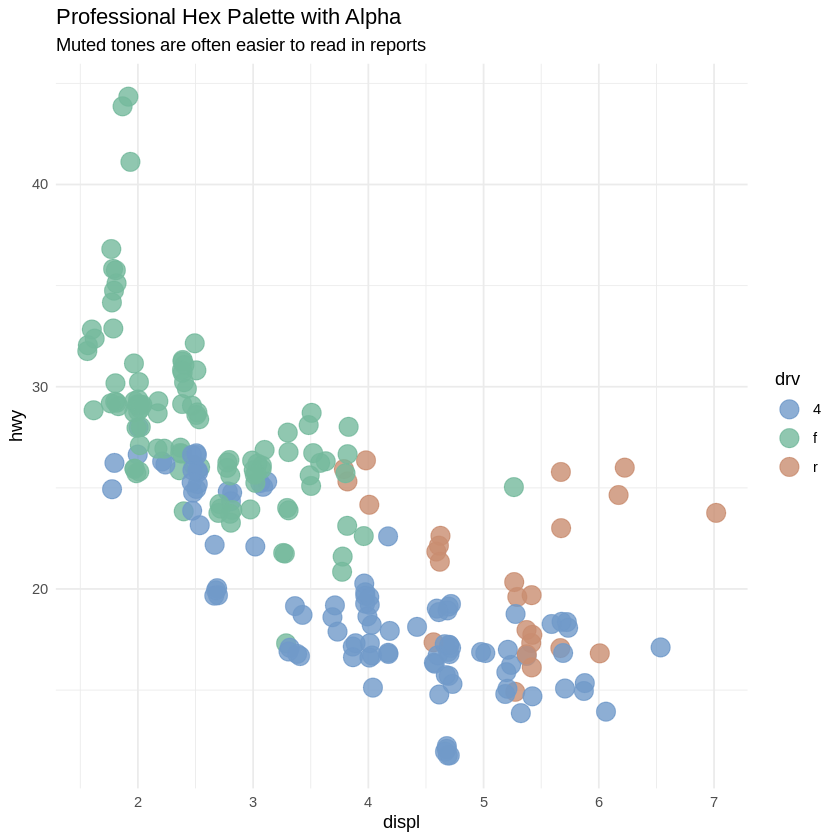

In [6]:
mpg %>%
  ggplot(aes(displ, hwy, color = drv)) +
  geom_jitter(size = 5, alpha = 0.8) + # স্বচ্ছতা যোগ করা হয়েছে
  scale_color_manual(values = c("4" = "#719AC9",
                                "f" = "#75B99C",
                                "r" = "#C98D71")) +
  theme_minimal() +
  labs(title = "Professional Hex Palette with Alpha",
       subtitle = "Muted tones are often easier to read in reports")

#### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):
- geom_jitter(): ডেটা পয়েন্টগুলো যেন একে অপরের ওপর না পড়ে, তাই বিন্দুগুলোকে সামান্য ছড়িয়ে দেয়।
- scale_color_brewer(): দ্রুত প্রফেশনাল প্যালেট ব্যবহারের জন্য।
- scale_color_manual(): প্রতিটি গ্রুপের জন্য নিজের পছন্দমতো রঙ সেট করতে।
- Hex Codes (#RRGGBB): রঙের সুনির্দিষ্ট শেড ব্যবহারের জন্য।
- alpha: বিন্দুর স্বচ্ছতা নিয়ন্ত্রণ করতে, যা ঘনবসতিপূর্ণ ডেটা পয়েন্ট দেখাতে সাহায্য করে।

**অভিনন্দন!** আপনি এখন যে কোনো গ্রাফে প্রফেশনাল কালার স্কিম ব্যবহার করতে সক্ষম।